# Problem 2 - Tiny Shakespeare Transformer


## Colab Setup
This setup cell installs helper packages, imports PyTorch, and selects GPU automatically. Tiny Shakespeare is downloaded by the next section.


In [1]:
import importlib, subprocess, sys

def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

for import_name, pip_name in [
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("tqdm", "tqdm"),
    ("nltk", "nltk"),
]:
    ensure_package(import_name, pip_name)

import json, math, os, random, re, time, urllib.request
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm

SEED = 4106
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Using device: cuda


## Tiny Shakespeare Data
The notebook downloads the canonical Tiny Shakespeare text. To match Homework 2 runtime assumptions, it uses the first 120,000 characters by default; set `MAX_CHARS = None` to train on the full text.


In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
tiny_path = DATA_DIR / "tinyshakespeare.txt"
if not tiny_path.exists():
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    urllib.request.urlretrieve(url, tiny_path)
raw_text = tiny_path.read_text(encoding="utf-8")
MAX_CHARS = 120_000
TEXT = raw_text[:MAX_CHARS] if MAX_CHARS else raw_text
chars = sorted(set(TEXT))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
encoded = [stoi[ch] for ch in TEXT]
print("Characters used:", len(TEXT), "Vocabulary:", len(chars))


Characters used: 120000 Vocabulary: 61


## Transformer Model and Training Utilities
The same causal character-level Transformer is used for the starting configuration, architecture sweep, and sequence length 50 run.


In [3]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_mb(model):
    return count_parameters(model) * 4 / (1024 ** 2)

def transformer_madds_per_sequence(seq_len, d_model, n_layers, dim_ff, vocab_size):
    # Approximate multiply-adds for one causal Transformer sequence.
    # Per encoder block: Q/K/V/O projections, attention score/value products, and two FFN projections.
    per_layer = 4 * seq_len * d_model * d_model + 2 * seq_len * seq_len * d_model + 2 * seq_len * d_model * dim_ff
    output_head = seq_len * d_model * vocab_size
    return int(n_layers * per_layer + output_head)

class CharWindowDataset(Dataset):
    def __init__(self, encoded, seq_len):
        self.x = []
        self.y = []
        for i in range(len(encoded) - seq_len):
            self.x.append(torch.tensor(encoded[i:i+seq_len], dtype=torch.long))
            self.y.append(torch.tensor(encoded[i+1:i+seq_len+1], dtype=torch.long))
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class CausalCharTransformer(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=128, n_heads=4, n_layers=2, dim_ff=256, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(seq_len, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)
    def forward(self, idx):
        batch_size, seq_len = idx.shape
        positions = torch.arange(seq_len, device=idx.device).unsqueeze(0).expand(batch_size, seq_len)
        x = self.token_embedding(idx) + self.position_embedding(positions)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=idx.device), diagonal=1).bool()
        x = self.encoder(x, mask=mask)
        return self.lm_head(x)

def evaluate_char_model(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            total_loss += loss.item() * yb.numel()
            pred = logits.argmax(dim=-1)
            total_correct += (pred == yb).sum().item()
            total_tokens += yb.numel()
    return total_loss / total_tokens, total_correct / total_tokens

def train_char_model(model, train_loader, val_loader, epochs=20, lr=3e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []
    start = time.perf_counter()
    for epoch in tqdm(range(1, epochs + 1), desc="Training", leave=False):
        model.train()
        train_loss_sum, train_tokens = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss_sum += loss.item() * yb.numel()
            train_tokens += yb.numel()
        val_loss, val_acc = evaluate_char_model(model, val_loader, criterion)
        history.append({
            "epoch": epoch,
            "train_loss": train_loss_sum / train_tokens,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_perplexity": math.exp(min(val_loss, 20)),
        })
    train_seconds = time.perf_counter() - start
    return history, train_seconds

@torch.no_grad()
def generate_text(model, stoi, itos, start_text, length=200, temperature=0.8):
    model.eval()
    ids = [stoi.get(ch, 0) for ch in start_text]
    for _ in range(length):
        context = torch.tensor([ids[-model.seq_len:]], dtype=torch.long, device=device)
        logits = model(context)[0, -1] / temperature
        probs = torch.softmax(logits, dim=-1)
        next_id = int(torch.multinomial(probs, num_samples=1).item())
        ids.append(next_id)
    return "".join(itos[i] for i in ids)


## Required Transformer Runs
The PDF requests blocks `1, 2, 4` crossed with heads `2, 4`, which is six unique combinations despite the text saying eight. The notebook runs all unique combinations exactly, plus the required sequence-length 20, 30, and 50 experiments.


Running baseline_seq20_blocks2_heads2


Running baseline_seq30_blocks2_heads2


Running arch_seq30_blocks1_heads2


Running arch_seq30_blocks1_heads4


Running arch_seq30_blocks2_heads2


Running arch_seq30_blocks2_heads4


Running arch_seq30_blocks4_heads2


Running arch_seq30_blocks4_heads4


Running seq50_blocks2_heads2


,label,seq_len,blocks,heads,d_model,train_loss,val_loss,val_accuracy,perplexity,train_seconds,inference_seconds,params,model_mb,madds_per_sequence
0,baseline_seq20_blocks2_heads2,20,2,2,128,1.740635,1.603152,0.511306,4.968668,32.674723,0.400466,414781,1.582264,8225280
1,baseline_seq30_blocks2_heads2,30,2,2,128,1.691845,1.541181,0.525334,4.670103,38.428974,0.486747,416061,1.587147,12491520
2,arch_seq30_blocks1_heads2,30,1,2,128,1.845766,1.682309,0.487269,5.377959,21.905576,0.351922,217789,0.830799,6362880
3,arch_seq30_blocks1_heads4,30,1,4,128,1.782775,1.643492,0.498922,5.173202,22.555888,0.419064,217789,0.830799,6362880
4,arch_seq30_blocks2_heads2,30,2,2,128,1.697008,1.548144,0.523388,4.702735,34.293908,0.538051,416061,1.587147,12491520
5,arch_seq30_blocks2_heads4,30,2,4,128,1.660197,1.520212,0.530355,4.573197,35.345194,0.545072,416061,1.587147,12491520
6,arch_seq30_blocks4_heads2,30,4,2,128,1.567524,1.421451,0.554377,4.143126,61.166770,0.800223,812605,3.099842,24748800
7,arch_seq30_blocks4_heads4,30,4,4,128,1.535291,1.392070,0.562927,4.023171,63.891667,0.854037,812605,3.099842,24748800
8,seq50_blocks2_heads2,50,2,2,128,1.654027,1.495196,0.537414,4.460211,50.530316,0.724364,418621,1.596912,21331200


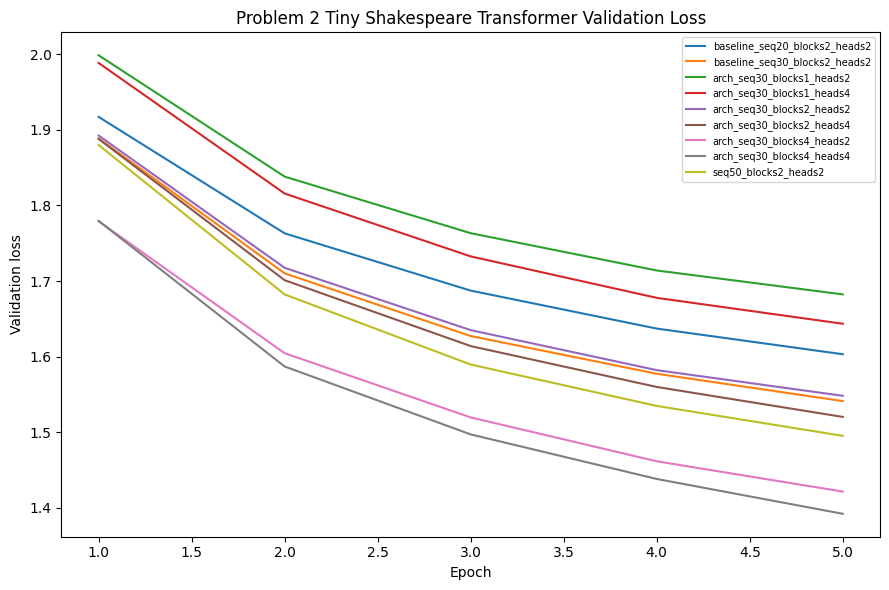

In [4]:
def run_tiny_experiment(label, seq_len, n_layers, n_heads, d_model=128, epochs=5, batch_size=128, lr=3e-4):
    if d_model % n_heads != 0:
        raise ValueError("d_model must be divisible by n_heads")
    dataset = CharWindowDataset(encoded, seq_len)
    n_train = int(0.8 * len(dataset))
    n_val = len(dataset) - n_train
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model = CausalCharTransformer(
        vocab_size=len(chars), seq_len=seq_len, d_model=d_model,
        n_heads=n_heads, n_layers=n_layers, dim_ff=4*d_model, dropout=0.2
    ).to(device)
    history, train_seconds = train_char_model(model, train_loader, val_loader, epochs=epochs, lr=lr)
    inference_start = time.perf_counter()
    _ = evaluate_char_model(model, val_loader, nn.CrossEntropyLoss())
    inference_seconds = time.perf_counter() - inference_start
    final = history[-1]
    sample = generate_text(model, stoi, itos, "ROMEO:", length=400, temperature=0.8)
    return {
        "label": label,
        "seq_len": seq_len,
        "blocks": n_layers,
        "heads": n_heads,
        "d_model": d_model,
        "train_loss": final["train_loss"],
        "val_loss": final["val_loss"],
        "val_accuracy": final["val_accuracy"],
        "perplexity": final["val_perplexity"],
        "train_seconds": train_seconds,
        "inference_seconds": inference_seconds,
        "params": count_parameters(model),
        "model_mb": model_size_mb(model),
        "madds_per_sequence": transformer_madds_per_sequence(seq_len, d_model, n_layers, 4*d_model, len(chars)),
        "sample_output": sample,
    }, history

runs = [
    ("baseline_seq20_blocks2_heads2", 20, 2, 2),
    ("baseline_seq30_blocks2_heads2", 30, 2, 2),
]
runs += [(f"arch_seq30_blocks{blocks}_heads{heads}", 30, blocks, heads)
         for blocks in [1, 2, 4] for heads in [2, 4]]
runs += [("seq50_blocks2_heads2", 50, 2, 2)]

results, histories = [], {}
for label, seq_len, blocks, heads in runs:
    print(f"Running {label}")
    row, history = run_tiny_experiment(label, seq_len, blocks, heads)
    results.append(row)
    histories[label] = history

results_df = pd.DataFrame(results)
display(results_df.drop(columns=["sample_output"]))
results_df.to_csv(OUTPUT_DIR / "problem2_transformer_metrics.csv", index=False)
(OUTPUT_DIR / "problem2_transformer_metrics.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
pd.DataFrame([{"label": r["label"], "sample_output": r["sample_output"]} for r in results]).to_csv(OUTPUT_DIR / "problem2_generated_text.csv", index=False)

plt.figure(figsize=(9, 6))
for label, history in histories.items():
    h = pd.DataFrame(history)
    plt.plot(h["epoch"], h["val_loss"], label=label)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Problem 2 Tiny Shakespeare Transformer Validation Loss")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "problem2_val_loss_curves.png", dpi=160)
plt.show()


## Homework 2 RNN Comparison Data
These verified prior rows are included so the Transformer results can be compared directly against the LSTM and GRU baselines and hyperparameter study.


In [5]:
baseline_rows = [["LSTM", 20, 1.1821, 1.6937, 0.5247, 5.4398, 75.63, 1.2777, 536797, 2.048, 10556160], ["GRU", 20, 1.2611, 1.6539, 0.5232, 5.2274, 53.31, 0.8491, 407005, 1.553, 7975680], ["LSTM", 30, 1.0297, 1.8244, 0.5245, 6.1991, 105.06, 1.8206, 536797, 2.048, 15834240], ["GRU", 30, 1.1171, 1.7009, 0.5257, 5.4788, 73.45, 1.2145, 407005, 1.553, 11963520], ["LSTM", 50, 0.8274, 2.061, 0.5177, 7.854, 164.86, 2.766, 536797, 2.048, 26390400], ["GRU", 50, 0.9412, 1.8334, 0.5282, 6.2549, 114.08, 1.8197, 407005, 1.553, 19939200]]
hparam_rows = [["LSTM small 1-layer", 1.2321, 1.6658, 0.5184, 5.29, 13.33, 0.1821, 111101, 0.424, 3183360], ["GRU small 1-layer", 1.1946, 1.72, 0.512, 5.5847, 12.28, 0.1535, 86269, 0.329, 2446080], ["LSTM medium 2-layer", 1.0841, 1.7505, 0.5271, 5.7573, 84.01, 1.7528, 536797, 2.048, 15834240], ["GRU medium 2-layer", 1.1475, 1.686, 0.5259, 5.3976, 58.74, 1.1875, 407005, 1.553, 11963520], ["LSTM medium 2-layer + FC", 1.0887, 1.7956, 0.5262, 6.0234, 84.82, 1.7783, 557597, 2.127, 16454400], ["GRU medium 2-layer + FC", 1.139, 1.7137, 0.5266, 5.5492, 59.96, 1.2363, 427805, 1.632, 12583680], ["LSTM large 3-layer + FC", 1.1553, 1.7043, 0.5344, 5.4973, 54.95, 0.5382, 1537213, 5.864, 45688320], ["GRU large 3-layer + FC", 1.1965, 1.6374, 0.5393, 5.1418, 45.33, 0.4591, 1175229, 4.483, 34874880]]
hw2_baseline = pd.DataFrame(baseline_rows, columns=["model", "seq_len", "train_loss", "val_loss", "val_accuracy", "perplexity", "train_seconds", "inference_seconds", "params", "model_mb", "madds_per_sequence"])
hw2_hparams = pd.DataFrame(hparam_rows, columns=["configuration", "train_loss", "val_loss", "val_accuracy", "perplexity", "train_seconds", "inference_seconds", "params", "model_mb", "madds_per_sequence"])
display(hw2_baseline)
display(hw2_hparams)
hw2_baseline.to_csv(OUTPUT_DIR / "problem2_hw2_rnn_baselines.csv", index=False)
hw2_hparams.to_csv(OUTPUT_DIR / "problem2_hw2_rnn_hyperparameters.csv", index=False)


,model,seq_len,train_loss,val_loss,val_accuracy,perplexity,train_seconds,inference_seconds,params,model_mb,madds_per_sequence
0,LSTM,20,1.1821,1.6937,0.5247,5.4398,75.63,1.2777,536797,2.048,10556160
1,GRU,20,1.2611,1.6539,0.5232,5.2274,53.31,0.8491,407005,1.553,7975680
2,LSTM,30,1.0297,1.8244,0.5245,6.1991,105.06,1.8206,536797,2.048,15834240
3,GRU,30,1.1171,1.7009,0.5257,5.4788,73.45,1.2145,407005,1.553,11963520
4,LSTM,50,0.8274,2.0610,0.5177,7.8540,164.86,2.7660,536797,2.048,26390400
5,GRU,50,0.9412,1.8334,0.5282,6.2549,114.08,1.8197,407005,1.553,19939200


,configuration,train_loss,val_loss,val_accuracy,perplexity,train_seconds,inference_seconds,params,model_mb,madds_per_sequence
0,LSTM small 1-layer,1.2321,1.6658,0.5184,5.2900,13.33,0.1821,111101,0.424,3183360
1,GRU small 1-layer,1.1946,1.7200,0.5120,5.5847,12.28,0.1535,86269,0.329,2446080
2,LSTM medium 2-layer,1.0841,1.7505,0.5271,5.7573,84.01,1.7528,536797,2.048,15834240
3,GRU medium 2-layer,1.1475,1.6860,0.5259,5.3976,58.74,1.1875,407005,1.553,11963520
4,LSTM medium 2-layer + FC,1.0887,1.7956,0.5262,6.0234,84.82,1.7783,557597,2.127,16454400
5,GRU medium 2-layer + FC,1.1390,1.7137,0.5266,5.5492,59.96,1.2363,427805,1.632,12583680
6,LSTM large 3-layer + FC,1.1553,1.7043,0.5344,5.4973,54.95,0.5382,1537213,5.864,45688320
7,GRU large 3-layer + FC,1.1965,1.6374,0.5393,5.1418,45.33,0.4591,1175229,4.483,34874880
